In [44]:
import pandas as  pd 
import numpy as np 
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [45]:
df = pd.read_csv('weight-height.csv')
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [46]:
df.shape

(10000, 3)

In [47]:
# We'll use only height col for this excerise ( Since it has Outliers) 
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Density'>

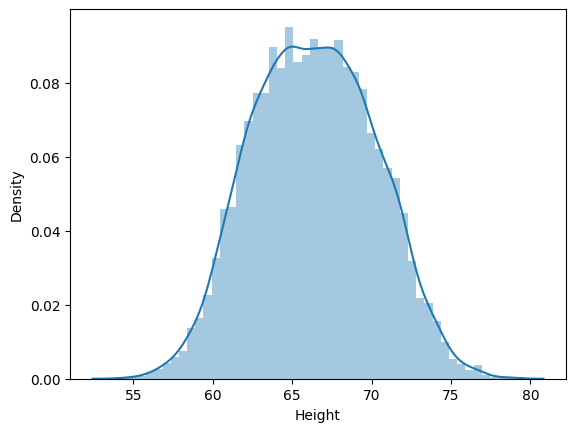

In [6]:
# lets the distribution 
sns.distplot(df['Height']) 

In [7]:
# Looks like a Normal Dist. -> GOOD 

<Axes: xlabel='Height'>

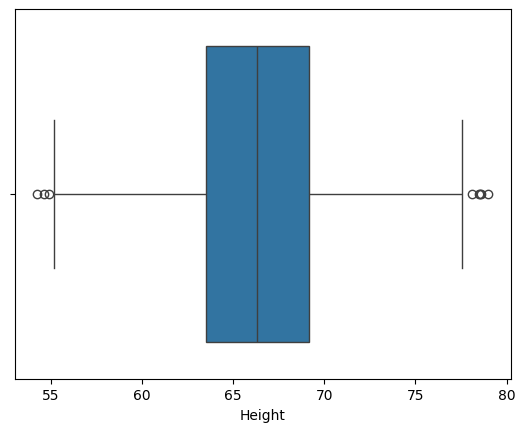

In [9]:
# Lets check Outliers 
sns.boxplot(x=df['Height'])

In [10]:
# Lets Use Percentiles for Having Boundiers to the data set and Handle Ouliers 

In [11]:
# Upper Percentile 
upper_limit = df['Height'].quantile(0.99)
upper_limit

np.float64(74.7857900583366)

In [13]:
# Lower Percentile 
lower_limit = df['Height'].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

### Important Note

While handling outliers, always keep the upper and lower percentile limits equal (e.g., 5th percentile to 95th percentile)   
to maintain balance and avoid bias in the dataset.

In [16]:
# Lets find the no. of ouliters 
df[(df['Height'] >= 74.78 ) | (df['Height'] <= 58.13 )]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


In [ ]:
# there are 201 Ouliter from the 10,000 rows 

In [17]:
# lets remove the outlier from the df 
new_df = df[(df['Height'] <= 74.78 ) & (df['Height'] >= 58.13 )]

In [19]:
# No Outliers 
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [21]:
# Lets see teh changes in Stats 
new_df['Height'].describe()

count    9799.000000
mean       66.363507
std         3.644267
min        58.134496
25%        63.577147
50%        66.317899
75%        69.119859
max        74.767447
Name: Height, dtype: float64

In [22]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

In [23]:
# count , Std , min, max has changed

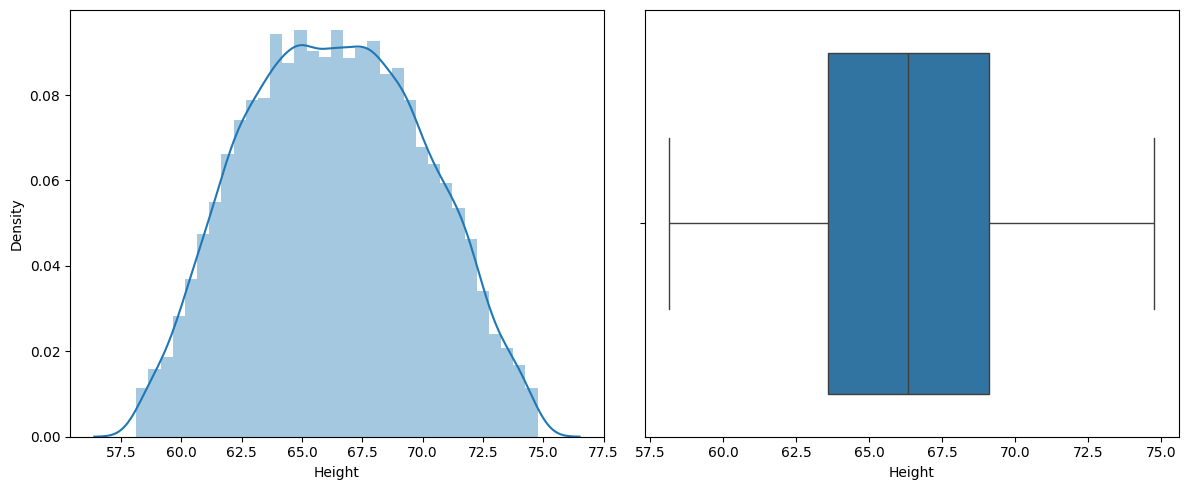

In [28]:
# lets see the dist. of new_df 
import matplotlib.pyplot as plt 

plt.figure(figsize=(12,5))

# Distplot
plt.subplot(1,2,1)
sns.distplot(new_df['Height'])

# BoxPlot
plt.subplot(1,2,2)
sns.boxplot(x=new_df['Height'])

plt.tight_layout()

In [29]:
# the Distribution has got thicker , and there are no outlier left 

### Capping (Winsorization)

- Extreme outlier values are replaced with boundary values instead of removing them.

> Winsorization is named after statistician Charles P. Winsor.

In [48]:
df['Height'] = np.where(df['Height'] >= upper_limit ,   # Condition 1 
        upper_limit,                     # if cond 1 is True 
        np.where(df['Height'] <= lower_limit ,  # if cond 1 is False , then Cond 2 
        lower_limit,                    # if Cond 2 is True 
        df['Height']))                  # if both cond False , then use this 

In [49]:
# After Capping the Shape of dataset is not changes but the values are 
df.shape

(10000, 3)

In [50]:
df['Height'].describe()   # changes compared to The original one 

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

<Axes: xlabel='Height'>

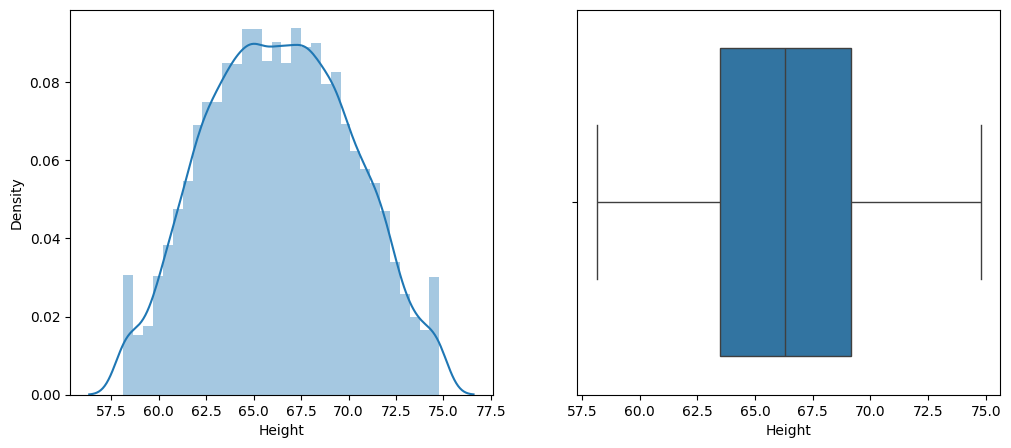

In [51]:
# Lets see the Dist and Boxplot 

plt.figure(figsize=(12,5))

# Distplot
plt.subplot(1,2,1)
sns.distplot(df['Height'])

# BoxPlot
plt.subplot(1,2,2)
sns.boxplot(x=df['Height'])



In [52]:
# the Bounderies are raised (Capped) , no outliers